# BreaKHis ResNet18 Training

## Objective

This notebook trains an image-only baseline model for binary breast histopathology classification using the BreaKHis dataset.

A pretrained ResNet18 architecture is used as the baseline convolutional neural network. The purpose of this stage is to establish an imaging-only benchmark before multimodal fusion with the clinical model.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Training imports loaded.")

Training imports loaded.


In [30]:
base_project_path = Path("/Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project")

outputs_path = base_project_path / "outputs"
figures_path = outputs_path / "figures"
metrics_path = outputs_path / "metrics"
reports_path = outputs_path / "reports"
models_path = base_project_path / "models"

figures_path.mkdir(parents=True, exist_ok=True)
metrics_path.mkdir(parents=True, exist_ok=True)
reports_path.mkdir(parents=True, exist_ok=True)
models_path.mkdir(parents=True, exist_ok=True)

print("Figures path:", figures_path)
print("Metrics path:", metrics_path)
print("Reports path:", reports_path)
print("Models path:", models_path)

Figures path: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs/figures
Metrics path: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs/metrics
Reports path: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs/reports
Models path: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/models


In [31]:
train_df = pd.read_csv(reports_path / "train_split.csv")
val_df = pd.read_csv(reports_path / "val_split.csv")
test_df = pd.read_csv(reports_path / "test_split.csv")

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 5536
Validation size: 1186
Test size: 1187


## Preprocessing Setup

This notebook reuses the split definitions created during exploratory analysis and rebuilds the preprocessing pipeline locally to ensure reproducibility. The same image size and normalization settings are used as in the preprocessing notebook.

In [32]:
image_size = (224, 224)

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

eval_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

print("Transforms ready.")

Transforms ready.


In [33]:
class BreakHisDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.label_map = {"benign": 0, "malignant": 1}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        with Image.open(row["filepath"]) as img:
            image = img.convert("RGB")

        label = self.label_map[row["label"]]

        if self.transform:
            image = self.transform(image)

        return image, label

In [34]:
train_dataset = BreakHisDataset(train_df, transform=train_transform)
val_dataset = BreakHisDataset(val_df, transform=eval_transform)
test_dataset = BreakHisDataset(test_df, transform=eval_transform)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 5536
Validation dataset: 1186
Test dataset: 1187


In [35]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 173
Validation batches: 38
Test batches: 38


In [36]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: mps


In [37]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print("Model parameter device:", next(model.parameters()).device)

Model parameter device: mps:0


## Smoke Test Training

A single-epoch training run is first performed to verify that the full pipeline works correctly before longer experiments are launched.

In [39]:
num_epochs = 1

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = accuracy_score(all_labels, all_preds)

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Accuracy: {epoch_val_acc:.4f}"
    )

Epoch 1/1 | Train Loss: 0.2557 | Val Loss: 0.1276 | Val Accuracy: 0.9578


## Full Baseline Training

After the successful smoke test, the image-only ResNet18 baseline was trained for five epochs to establish a stronger performance benchmark for later comparison with multimodal fusion models.

In [40]:
num_epochs = 5

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)

        if batch_idx % 20 == 0:
            print(f"Epoch {epoch+1}, Training batch {batch_idx}/{len(train_loader)}")

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = accuracy_score(all_labels, all_preds)

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Accuracy: {epoch_val_acc:.4f}"
    )

Epoch 1, Training batch 0/173
Epoch 1, Training batch 20/173
Epoch 1, Training batch 40/173
Epoch 1, Training batch 60/173
Epoch 1, Training batch 80/173
Epoch 1, Training batch 100/173
Epoch 1, Training batch 120/173
Epoch 1, Training batch 140/173
Epoch 1, Training batch 160/173
Epoch 1/5 | Train Loss: 0.1306 | Val Loss: 0.0817 | Val Accuracy: 0.9705
Epoch 2, Training batch 0/173
Epoch 2, Training batch 20/173
Epoch 2, Training batch 40/173
Epoch 2, Training batch 60/173
Epoch 2, Training batch 80/173
Epoch 2, Training batch 100/173
Epoch 2, Training batch 120/173
Epoch 2, Training batch 140/173
Epoch 2, Training batch 160/173
Epoch 2/5 | Train Loss: 0.0861 | Val Loss: 0.0772 | Val Accuracy: 0.9705
Epoch 3, Training batch 0/173
Epoch 3, Training batch 20/173
Epoch 3, Training batch 40/173
Epoch 3, Training batch 60/173
Epoch 3, Training batch 80/173
Epoch 3, Training batch 100/173
Epoch 3, Training batch 120/173
Epoch 3, Training batch 140/173
Epoch 3, Training batch 160/173
Epoch 3/

In [41]:
torch.save(model.state_dict(), models_path / "breakhis_resnet18_baseline.pth")
print("Model saved.")

Model saved.


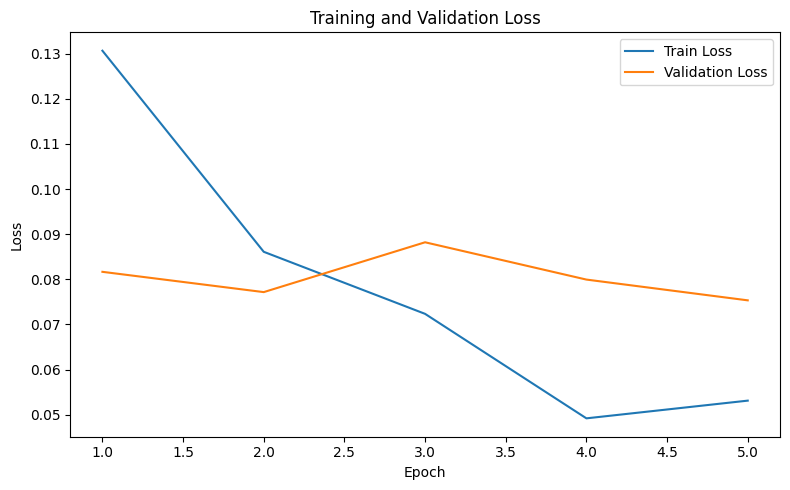

In [42]:
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs + 1), train_losses, label="Train Loss")
plt.plot(range(1, num_epochs + 1), val_losses, label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig(figures_path / "figure_05_train_val_loss.png", dpi=300)
plt.savefig(figures_path / "figure_05_train_val_loss.pdf")

plt.show()

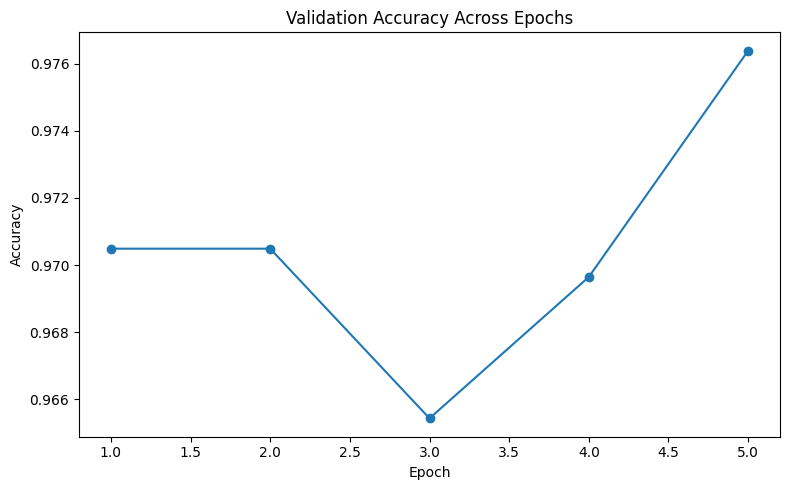

In [43]:
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs + 1), val_accuracies, marker="o")

plt.title("Validation Accuracy Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.savefig(figures_path / "figure_06_val_accuracy.png", dpi=300)
plt.savefig(figures_path / "figure_06_val_accuracy.pdf")

plt.show()

The baseline CNN demonstrated stable convergence across five epochs, achieving a peak validation accuracy of 97.64%, indicating strong discriminative capability on the BreakHis binary classification task

In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

model.eval()

test_preds = []
test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_acc = accuracy_score(test_labels, test_preds)
test_precision = precision_score(test_labels, test_preds)
test_recall = recall_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds)

print("Test Accuracy:", round(test_acc, 4))
print("Precision:", round(test_precision, 4))
print("Recall:", round(test_recall, 4))
print("F1 Score:", round(test_f1, 4))

Test Accuracy: 0.9781
Precision: 0.9805
Recall: 0.9877
F1 Score: 0.9841


In [45]:
cm = confusion_matrix(test_labels, test_preds)
print(cm)

[[356  16]
 [ 10 805]]


In [46]:
print(classification_report(test_labels, test_preds))

              precision    recall  f1-score   support

           0       0.97      0.96      0.96       372
           1       0.98      0.99      0.98       815

    accuracy                           0.98      1187
   macro avg       0.98      0.97      0.97      1187
weighted avg       0.98      0.98      0.98      1187



In [47]:
results_df = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1_score"],
    "value": [test_acc, test_precision, test_recall, test_f1]
})

results_df.to_csv(metrics_path / "resnet18_test_metrics.csv", index=False)
print(results_df)

      metric     value
0   accuracy  0.978096
1  precision  0.980512
2     recall  0.987730
3   f1_score  0.984108


In [49]:
import sys
!{sys.executable} -m pip install seaborn

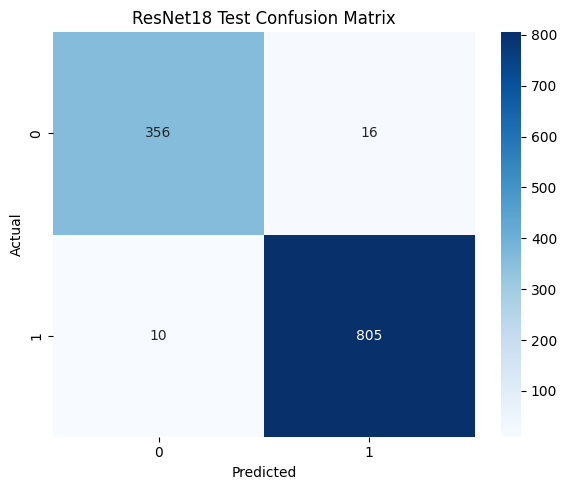

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("ResNet18 Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(figures_path / "resnet18_confusion_matrix.png", dpi=300)
plt.show()

The ResNet18 baseline achieved strong performance on the BreakHis dataset, with 97.81% test accuracy and 98.41% F1-score. These results establish a strong unimodal image baseline for comparison with subsequent multimodal fusion models.
